In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/railway-track-fault-detection-dataset1-rail/Dataset 1_Rail/Validiation/Defective/aug_prefix_0_9530.jpg
/kaggle/input/railway-track-fault-detection-dataset1-rail/Dataset 1_Rail/Validiation/Defective/aug_prefix_0_9071.jpg
/kaggle/input/railway-track-fault-detection-dataset1-rail/Dataset 1_Rail/Validiation/Defective/aug_prefix_0_8734.jpg
/kaggle/input/railway-track-fault-detection-dataset1-rail/Dataset 1_Rail/Validiation/Defective/aug_prefix_0_9023.jpg
/kaggle/input/railway-track-fault-detection-dataset1-rail/Dataset 1_Rail/Validiation/Defective/aug_prefix_0_8706.jpg
/kaggle/input/railway-track-fault-detection-dataset1-rail/Dataset 1_Rail/Validiation/Defective/download (3).jpeg
/kaggle/input/railway-track-fault-detection-dataset1-rail/Dataset 1_Rail/Validiation/Defective/download (4).jpeg
/kaggle/input/railway-track-fault-detection-dataset1-rail/Dataset 1_Rail/Validiation/Defective/aug_prefix_0_9787.jpg
/kaggle/input/railway-track-fault-detection-dataset1-rail/Dataset 1_Rail

In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt

import tensorflow as tf
from keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

2025-04-21 20:39:13.282030: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745267953.489142      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745267953.543265      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
import os

for dirname, subdirs, files in os.walk('/kaggle/input/railway-track-fault-detection'):
    print(f"📂 Directory: {dirname}")
    for subdir in subdirs:
        print(f"  📁 Subfolder: {subdir}")
    for file in files[:5]:
        print(f"  📄 File: {file}")

In [4]:
import os

print("Top-level folders in /kaggle/input:")
print(os.listdir("/kaggle/input"))


Top-level folders in /kaggle/input:
['railway-track-fault-detection-dataset1-rail']


In [5]:
import os

for dirname, subdirs, files in os.walk('/kaggle/input/railway-track-fault-detection-dataset1-rail'):
    print(f"📂 Directory: {dirname}")
    for subdir in subdirs:
        print(f"  📁 Subfolder: {subdir}")
    for file in files[:5]:  # Show only first 5 files to avoid spam
        print(f"  📄 File: {file}")


📂 Directory: /kaggle/input/railway-track-fault-detection-dataset1-rail
  📁 Subfolder: Dataset 1_Rail
📂 Directory: /kaggle/input/railway-track-fault-detection-dataset1-rail/Dataset 1_Rail
  📁 Subfolder: Validiation
  📁 Subfolder: Test
  📁 Subfolder: Train
📂 Directory: /kaggle/input/railway-track-fault-detection-dataset1-rail/Dataset 1_Rail/Validiation
  📁 Subfolder: Defective
  📁 Subfolder: Non Defective
📂 Directory: /kaggle/input/railway-track-fault-detection-dataset1-rail/Dataset 1_Rail/Validiation/Defective
  📄 File: aug_prefix_0_9530.jpg
  📄 File: aug_prefix_0_9071.jpg
  📄 File: aug_prefix_0_8734.jpg
  📄 File: aug_prefix_0_9023.jpg
  📄 File: aug_prefix_0_8706.jpg
📂 Directory: /kaggle/input/railway-track-fault-detection-dataset1-rail/Dataset 1_Rail/Validiation/Non Defective
  📄 File: IMG_20201114_100853.jpg
  📄 File: aug_prefix_0_9661.jpg
  📄 File: IMG_20201114_101031.jpg
  📄 File: IMG_20201114_100134.jpg
  📄 File: aug_prefix_0_8840.jpg
📂 Directory: /kaggle/input/railway-track-fault-

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Rescaling images
datagen = ImageDataGenerator(rescale=1./255)

# Train generator
train_generator = datagen.flow_from_directory(
    '/kaggle/input/railway-track-fault-detection-dataset1-rail/Dataset 1_Rail/Train',
    target_size=(380, 380),
    batch_size=16,
    class_mode='binary',
    classes=['Non Defective', 'Defective']
)

# Validation generator
validation_generator = datagen.flow_from_directory(
    '/kaggle/input/railway-track-fault-detection-dataset1-rail/Dataset 1_Rail/Validiation',
    target_size=(380, 380),
    batch_size=16,
    class_mode='binary',
    classes=['Non Defective', 'Defective']
)


Found 560 images belonging to 2 classes.
Found 158 images belonging to 2 classes.


In [7]:
# Test generator (no shuffling so we preserve image order)
test_generator = datagen.flow_from_directory(
    '/kaggle/input/railway-track-fault-detection-dataset1-rail/Dataset 1_Rail/Test',
    target_size=(380, 380),
    batch_size=16,
    class_mode='binary',
    shuffle=False,
    classes=['Non Defective', 'Defective']
)


Found 80 images belonging to 2 classes.


In [8]:
train_class_distribution = train_generator.class_indices
validation_class_distribution = validation_generator.class_indices
test_class_distribution = test_generator.class_indices

print(f"Training class distribution: {train_class_distribution}")
print(f"Validation class distribution: {validation_class_distribution}")
print(f"test class distribution: {test_class_distribution}")

Training class distribution: {'Non Defective': 0, 'Defective': 1}
Validation class distribution: {'Non Defective': 0, 'Defective': 1}
test class distribution: {'Non Defective': 0, 'Defective': 1}


In [ ]:
#the first 4 image and dimensions
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i in range(4):
    img_path = os.path.join(train_generator.directory, train_generator.filenames[i])
    img = image.load_img(img_path)
    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(f"Image {i+1}: {img.size}")
plt.tight_layout()
plt.show()

In [ ]:
#class distribütion in training set
train_class_counts = [train_generator.labels.tolist().count(i) for i in range(len(train_class_distribution))]

plt.figure(figsize=(10, 6))
bars = plt.bar(train_class_distribution.keys(), train_class_counts, color='skyblue', edgecolor='black')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10, 
             str(int(bar.get_height())), ha='center', va='bottom', fontsize=12)

plt.title('Class Distribution in Training Set', fontsize=16, fontweight='bold')
plt.xlabel('Class', fontsize=14)
plt.ylabel('Number of Samples', fontsize=14)
plt.tight_layout()
plt.show()

In [11]:
import tensorflow as tf
from tensorflow.keras.applications import InceptionResNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout,BatchNormalization, LeakyReLU , Conv2D
from tensorflow.keras.models import Model
from tensorflow.keras.layers import *
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.regularizers import l2
from tensorflow.keras.metrics import AUC, Precision, Recall
from tensorflow.keras.layers import GaussianNoise
from tensorflow.keras import backend as K


# Load pre-trained InceptionResNetV2
base_model = InceptionResNetV2(weights='imagenet', include_top=False, input_shape=(380, 380, 3))

# Freeze all layers initially
for layer in base_model.layers:
    layer.trainable = False  

# --- ADD CUSTOM CLASSIFICATION HEAD WITH MULTI-HEAD ATTENTION ---
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

# --- IMPLEMENT MULTI-HEAD ATTENTION MECHANISM ---
# Reshape to prepare features for attention
x_reshaped = Reshape((1, x.shape[-1]))(x)

# Implement multi-head attention (3 heads)
num_heads = 3
head_outputs = []

for i in range(num_heads):
    # Each attention head
    attention = Dense(64, activation='relu', name=f'attention_projection_{i}')(x_reshaped)
    attention = Dense(1, activation='tanh', name=f'attention_score_{i}')(attention)
    attention = Flatten()(attention)
    attention_weights = Activation('softmax')(attention)
    attention_weights = RepeatVector(x.shape[-1])(attention_weights)
    attention_weights = Permute([2, 1])(attention_weights)
    
    # Apply attention weights
    head_output = Multiply()([x_reshaped, attention_weights])
    head_output = Lambda(lambda x: K.sum(x, axis=1))(head_output)
    head_outputs.append(head_output)

# Combine attention heads
if num_heads > 1:
    context_vector = Concatenate()(head_outputs)
    # Project back to original dimension
    context_vector = Dense(x.shape[-1], activation='relu')(context_vector)
else:
    context_vector = head_outputs[0]

# --- SKIP CONNECTION ---
# Add skip connection from after GlobalAveragePooling to after attention
context_vector = Add()([context_vector, x])

# --- FINAL LAYERS WITH ENHANCED REGULARIZATION ---
x = GaussianNoise(0.05)(context_vector)
x = Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.005))(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.005))(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

# --- OUTPUT LAYER ---
output = Dense(1, activation='sigmoid')(x)

# --- CREATE MODEL ---
model = Model(inputs=base_model.input, outputs=output)

# --- COMPILE MODEL ---
# Add gradient clipping to prevent exploding gradients

optimizer = Adam(learning_rate=0.0001, clipnorm=1.0)
model.compile(optimizer=optimizer,  
              loss='binary_crossentropy',  
              metrics=['accuracy', 'AUC', 'Precision', 'Recall'])

# # Print model summary
# print(model.summary())

# --- ENHANCED CALLBACKS ---
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint('best_model.keras', monitor='val_auc', mode='max', 
                             save_best_only=True, verbose=1)
callbacks_list = [lr_scheduler,early_stop, checkpoint]



# --- TRAIN THE MODEL ---
history = model.fit(
    train_generator, 
    epochs=70,  
    validation_data=validation_generator, 
    batch_size=16,  
    verbose=1, 
    callbacks=callbacks_list
)











 
    







I0000 00:00:1745267971.781772      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


219055592/219055592 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step
Epoch 1/70


I0000 00:00:1745268027.580634     115 service.cc:148] XLA service 0x7cc47c0036b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1745268027.581467     115 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1745268032.879215     115 cuda_dnn.cc:529] Loaded cuDNN version 90300


 1/35 ━━━━━━━━━━━━━━━━━━━━ 32:18 57s/step - AUC: 0.3833 - Precision: 0.3333 - Recall: 0.5000 - accuracy: 0.4375 - loss: 4.3558

I0000 00:00:1745268045.071175     115 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


35/35 ━━━━━━━━━━━━━━━━━━━━ 120s 2s/step - AUC: 0.6995 - Precision: 0.6362 - Recall: 0.6660 - accuracy: 0.6534 - loss: 3.8056 - val_AUC: 0.9265 - val_Precision: 0.9219 - val_Recall: 0.7564 - val_accuracy: 0.8481 - val_loss: 3.4442 - learning_rate: 1.0000e-04
Epoch 2/70
35/35 ━━━━━━━━━━━━━━━━━━━━ 35s 833ms/step - AUC: 0.9432 - Precision: 0.8574 - Recall: 0.8720 - accuracy: 0.8765 - loss: 3.3274 - val_AUC: 0.9770 - val_Precision: 1.0000 - val_Recall: 0.6026 - val_accuracy: 0.8038 - val_loss: 3.4412 - learning_rate: 1.0000e-04
Epoch 3/70
35/35 ━━━━━━━━━━━━━━━━━━━━ 35s 853ms/step - AUC: 0.9624 - Precision: 0.9263 - Recall: 0.8944 - accuracy: 0.9132 - loss: 3.2296 - val_AUC: 0.9840 - val_Precision: 1.0000 - val_Recall: 0.6795 - val_accuracy: 0.8418 - val_loss: 3.3145 - learning_rate: 1.0000e-04
Epoch 4/70
35/35 ━━━━━━━━━━━━━━━━━━━━ 37s 910ms/step - AUC: 0.9686 - Precision: 0.9719 - Recall: 0.8993 - accuracy: 0.9360 - loss: 3.1594 - val_AUC: 0.9851 - val_Precision: 0.9831 - val_Recall: 0.7436

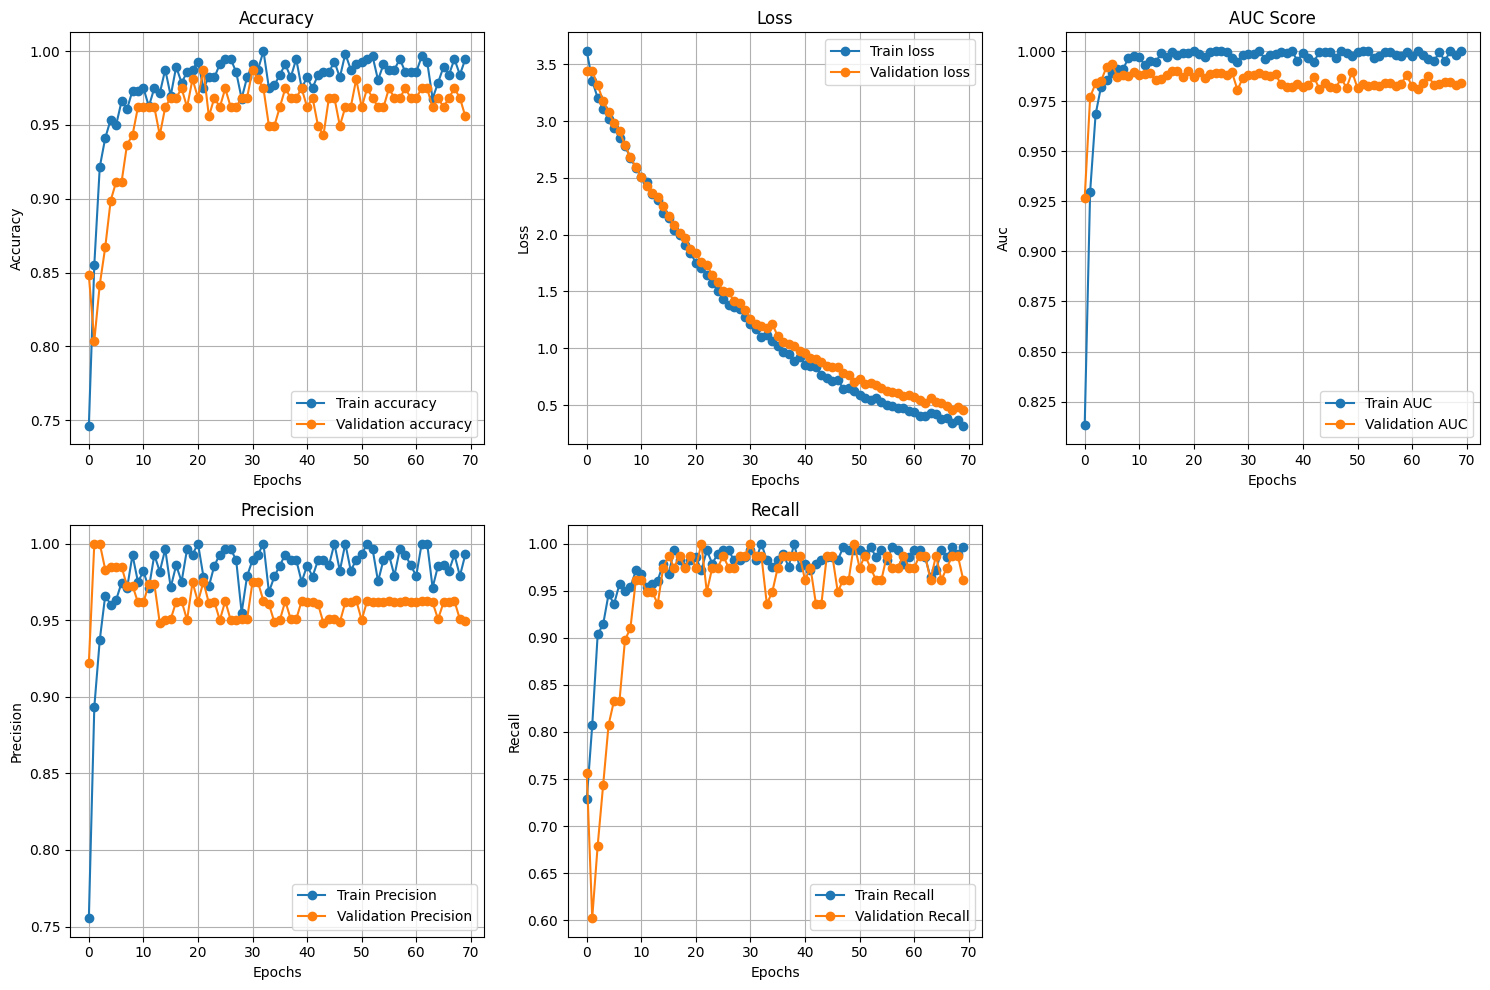

In [ ]:
# --- PLOTTING FUNCTION ---
def plot_metrics(history, fine_tune_history=None):
    """ Function to plot training history """
    metrics = ['accuracy', 'loss', 'AUC', 'Precision', 'Recall']
    titles = ['Accuracy', 'Loss', 'AUC Score', 'Precision', 'Recall']

    plt.figure(figsize=(15, 10))

    for i, metric in enumerate(metrics):
        plt.subplot(2, 3, i + 1)
        plt.plot(history.history[metric], label=f"Train {metric}",marker='o')
        plt.plot(history.history[f"val_{metric}"], label=f"Validation {metric}",marker='o')
        
        if fine_tune_history:  # If fine-tuning was done, add its history
            plt.plot(fine_tune_history.history[metric], label=f"Fine-tuned Train {metric}", linestyle="dashed")
            plt.plot(fine_tune_history.history[f"val_{metric}"], label=f"Fine-tuned Validation {metric}", linestyle="dashed")
        
        plt.xlabel("Epochs")
        plt.ylabel(metric.capitalize())
        plt.title(titles[i])
        plt.legend()
        plt.grid()

    plt.tight_layout()
    plt.show()

# --- PLOT TRAINING & FINE-TUNING RESULTS ---
plot_metrics(history)

In [16]:
from sklearn.metrics import classification_report
import numpy as np

# Predict on the test set using generator
y_pred_probs = model.predict(test_generator, verbose=1)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()  # Convert to 0 or 1

# Get true labels from the generator
y_true = test_generator.classes  # Ground truth labels

# Generate classification report
report = classification_report(y_true, y_pred, target_names=['Non-Defective (0)', 'Defective (1)'])
print("Classification Report:\n", report)


5/5 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step
Classification Report:
                    precision    recall  f1-score   support

Non-Defective (0)       0.95      0.97      0.96        40
    Defective (1)       0.97      0.95      0.96        40

         accuracy                           0.96        80
        macro avg       0.96      0.96      0.96        80
     weighted avg       0.96      0.96      0.96        80



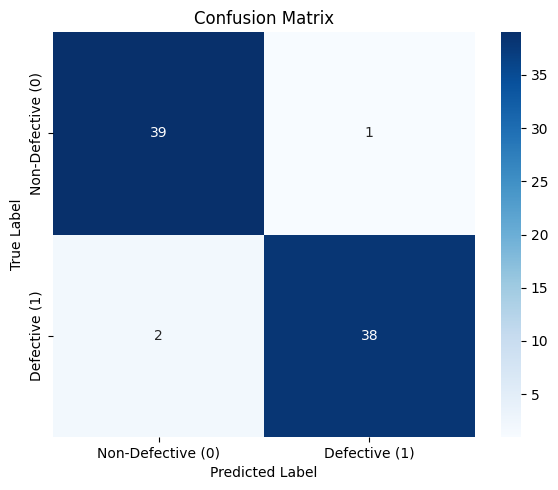

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Compute confusion matrix using test_generator
cm = confusion_matrix(test_generator.classes, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Defective (0)', 'Defective (1)'],
            yticklabels=['Non-Defective (0)', 'Defective (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()


In [20]:
# --- EVALUATE THE MODEL USING test_generator ---
test_loss, test_accuracy, test_auc, test_precision, test_recall = model.evaluate(test_generator, verbose=1)

print(f"Final Test Accuracy: {test_accuracy:.4f}")
print(f"Final Test Loss: {test_loss:.4f}")
print(f"Final Test AUC: {test_auc:.4f}")
print(f"Final Test Precision: {test_precision:.4f}")
print(f"Final Test Recall: {test_recall:.4f}")


5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - AUC: 0.6602 - Precision: 0.6303 - Recall: 0.6222 - accuracy: 0.9701 - loss: 0.4010      
Final Test Accuracy: 0.9625
Final Test Loss: 0.4028
Final Test AUC: 0.9922
Final Test Precision: 0.9744
Final Test Recall: 0.9500


In [21]:
# Evaluate model on test set using test_generator
results = model.evaluate(test_generator, verbose=1)

# Print evaluation results
print("\nModel Evaluation Metrics on Test Set:")
print(f"Loss: {results[0]:.4f}")
print(f"Accuracy: {results[1]:.4f}")
print(f"AUC: {results[2]:.4f}")
print(f"Precision: {results[3]:.4f}")
print(f"Recall: {results[4]:.4f}")


5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - AUC: 0.6602 - Precision: 0.6303 - Recall: 0.6222 - accuracy: 0.9701 - loss: 0.4010      

Model Evaluation Metrics on Test Set:
Loss: 0.4028
Accuracy: 0.9625
AUC: 0.9922
Precision: 0.9744
Recall: 0.9500


In [22]:
import numpy as np

# Predict probabilities using generator
y_pred_probs = model.predict(test_generator)

# Convert to binary labels (0 = Non-Defective, 1 = Defective)
y_pred = (y_pred_probs > 0.5).astype(int)

# True labels from generator
Y_test = test_generator.classes

# Compare first 10 predictions
for i in range(10):
    print(f"Actual: {Y_test[i]}, Predicted: {y_pred[i][0]}, Probability: {y_pred_probs[i][0]:.4f}")


5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step
Actual: 0, Predicted: 0, Probability: 0.0001
Actual: 0, Predicted: 0, Probability: 0.0004
Actual: 0, Predicted: 0, Probability: 0.0074
Actual: 0, Predicted: 0, Probability: 0.0002
Actual: 0, Predicted: 0, Probability: 0.0000
Actual: 0, Predicted: 0, Probability: 0.0000
Actual: 0, Predicted: 0, Probability: 0.0000
Actual: 0, Predicted: 0, Probability: 0.0027
Actual: 0, Predicted: 0, Probability: 0.0000
Actual: 0, Predicted: 0, Probability: 0.0001


1/1 ━━━━━━━━━━━━━━━━━━━━ 16s 16s/step


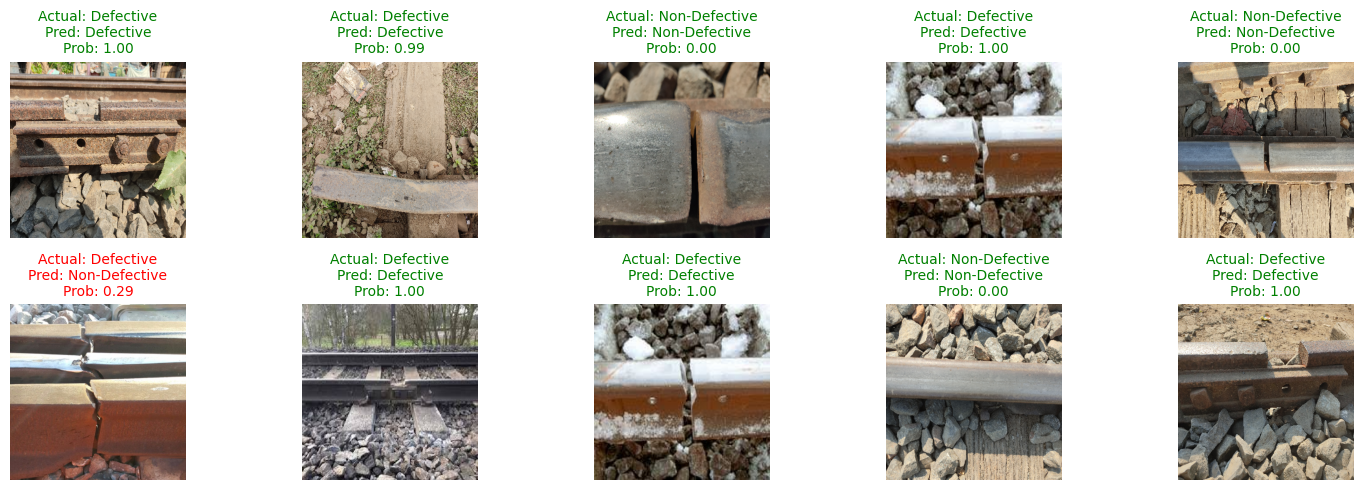

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Extract all test images and labels
X_test, Y_test = [], []
for i in range(len(test_generator)):
    x_batch, y_batch = test_generator[i]
    X_test.extend(x_batch)
    Y_test.extend(y_batch)

X_test = np.array(X_test)
Y_test = np.array(Y_test)

# Select random test samples
num_samples = 10  # Number of images to display
indices = np.random.choice(len(X_test), num_samples, replace=False)

# Predict probabilities on selected samples
y_pred_probs = model.predict(X_test[indices])
y_pred = (y_pred_probs > 0.5).astype(int)

# Plot images with actual and predicted labels
plt.figure(figsize=(15, 5))

for i, idx in enumerate(indices):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[idx])
    plt.axis('off')

    # Labels
    actual_label = "Defective" if Y_test[idx] == 1 else "Non-Defective"
    predicted_label = "Defective" if y_pred[i][0] == 1 else "Non-Defective"
    prob = y_pred_probs[i][0]

    # Title with probability
    plt.title(f"Actual: {actual_label}\nPred: {predicted_label}\nProb: {prob:.2f}",
              fontsize=10, color='green' if actual_label == predicted_label else 'red')

plt.tight_layout()
plt.show()
